In [5]:
pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 38.7 MB/s eta 0:00:00


# text extractor and **draws** text blox with lines in



Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete✅ Preprocessed image saved: /content/drive/MyDrive/Sketch2Code_Dataset_new/test_sketches_preprocessed/preprocessed_uizard.png
Detected & replaced 29 text blocks (merged from both OCRs).


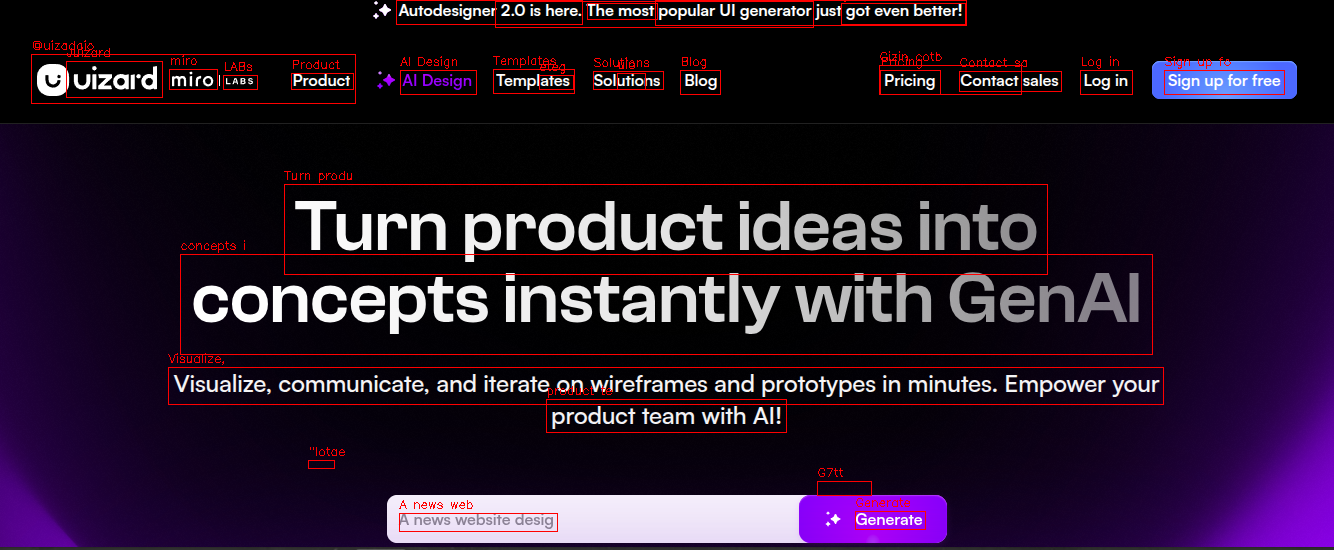

('/content/drive/MyDrive/Sketch2Code_Dataset_new/test_sketches_preprocessed/preprocessed_uizard.png',
 [[np.int64(396),
   np.int64(0),
   np.int64(582),
   np.int64(24),
   'Autodesigner 2.0 is here.',
   np.float64(0.6515884496890308)],
  [np.int64(587),
   np.int64(3),
   np.int64(657),
   np.int64(19),
   'The most',
   np.float64(0.98537115618169)],
  [np.int64(655),
   np.int64(0),
   np.int64(966),
   np.int64(25),
   'popular Ul generator just got even better!',
   np.float64(0.7813088032529582)],
  [np.int64(66),
   np.int64(61),
   np.int64(162),
   np.int64(97),
   'Juizard',
   np.float64(0.9816628966930311)],
  [np.int64(169),
   np.int64(69),
   np.int64(217),
   np.int64(89),
   'miro',
   np.float64(0.9821592291952369)],
  [np.int64(223),
   np.int64(75),
   np.int64(257),
   np.int64(89),
   'LABs',
   np.float64(0.277869868016713)],
  [np.int64(291),
   np.int64(73),
   np.int64(353),
   np.int64(89),
   'Product',
   np.float64(0.9997967868208969)],
  [np.int64(400),

In [7]:
import cv2
import numpy as np
import os
import easyocr
from google.colab.patches import cv2_imshow
import random

# Initialize both OCR readers
reader_standard = easyocr.Reader(['en'], gpu=True)
reader_handwritten = easyocr.Reader(['en'], gpu=True)

def preprocess_ui_image(image_path, output_folder="/content/drive/MyDrive/Sketch2Code_Dataset_new/test_sketches_preprocessed/", show=False):
    """
    Universal OCR for UI sketches (web-based + hand-drawn)
    - Enhances faint handwriting
    - Combines results from both OCR models
    - Replaces text with placeholder boxes
    - Saves the preprocessed image to Drive
    """

    # Read image
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    # Create output folder if not exists
    os.makedirs(output_folder, exist_ok=True)

    # Extract filename from input path
    filename = os.path.basename(image_path)
    save_path = os.path.join(output_folder, f"preprocessed_{filename}")

    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 1: Enhance handwriting contrast adaptively
    gray = cv2.equalizeHist(gray)
    if np.mean(gray) > 130:
        gray = 255 - gray

    # Adaptive threshold to make handwriting clear
    adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY_INV, 15, 8)

    # Denoise
    denoised = cv2.fastNlMeansDenoising(adaptive, None, 15, 7, 21)

    # Step 2: Run both OCR models
    results_standard = reader_standard.readtext(img, paragraph=False, detail=1)
    results_hand = reader_handwritten.readtext(denoised, paragraph=True, detail=1)

    # Combine results
    all_results = results_standard + results_hand

    # Step 3: Filter overlapping detections (IOU-based fusion)
    def iou(box1, box2):
        x11, y11, x12, y12 = box1
        x21, y21, x22, y22 = box2
        xi1, yi1, xi2, yi2 = max(x11, x21), max(y11, y21), min(x12, x22), min(y12, y22)
        inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
        box1_area = (x12 - x11) * (y12 - y11)
        box2_area = (x22 - x21) * (y22 - y21)
        return inter_area / float(box1_area + box2_area - inter_area + 1e-6)

    final_boxes = []
    for res in all_results:
        if len(res) < 2:
            continue
        bbox, text = res[:2]
        conf = res[2] if len(res) > 2 else 1.0
        if not text.strip() or conf < 0.25:
            continue
        pts = np.array(bbox).astype(int)
        x1, y1, x2, y2 = np.min(pts[:, 0]), np.min(pts[:, 1]), np.max(pts[:, 0]), np.max(pts[:, 1])
        skip = False
        for fb in final_boxes:
            if iou((x1, y1, x2, y2), fb[:4]) > 0.5:
                skip = True
                break
        if not skip:
            final_boxes.append([x1, y1, x2, y2, text, conf])

    output = img.copy()

    # Step 4: Replace every text region with placeholder + adaptive inner lines
    for (x1, y1, x2, y2, text, conf) in final_boxes:
        pad_x = int(0.01 * w)
        pad_y = int(0.005 * h)
        x1, y1 = max(0, x1 - pad_x), max(0, y1 - pad_y)
        x2, y2 = min(w, x2 + pad_x), min(h, y2 + pad_y)

        # Determine median color of background
        sub_region = img[max(0, y1 - 5):min(h, y2 + 5), max(0, x1 - 5):min(w, x2 + 5)]
        if sub_region.size > 0:
            median_color = np.median(sub_region.reshape(-1, 3), axis=0).astype(int)
            color_tuple = tuple(int(c) for c in median_color)
        else:
            color_tuple = (255, 255, 255)

        # Fill and draw light border
        cv2.rectangle(output, (x1, y1), (x2, y2), color_tuple, -1)
        pencil_gray = random.randint(200, 230)
        cv2.rectangle(output, (x1, y1), (x2, y2), (pencil_gray, pencil_gray, pencil_gray), 1, cv2.LINE_AA)

        # Inner horizontal lines
        box_height = y2 - y1
        if box_height < 40:
            n_lines = 1
        elif box_height < 80:
            n_lines = 2
        elif box_height < 120:
            n_lines = 3
        elif box_height < 180:
            n_lines = 5
        else:
            n_lines = 7

        line_spacing = int(box_height / (n_lines + 1))
        underline_color = (190, 190, 190)

        for i in range(1, n_lines + 1):
            y_line = y1 + i * line_spacing
            jitter_left = random.randint(-2, 2)
            jitter_right = random.randint(-2, 2)
            cv2.line(
                output,
                (x1 + 10 + jitter_left, y_line),
                (x2 - 10 + jitter_right, y_line),
                underline_color,
                1,
                cv2.LINE_AA
            )

    # Step 5: Save to Drive
    cv2.imwrite(save_path, cv2.cvtColor(output, cv2.COLOR_RGB2BGR))
    print(f"✅ Preprocessed image saved: {save_path}")
    print(f"Detected & replaced {len(final_boxes)} text blocks (merged from both OCRs).")

    if show:
        vis = img.copy()
        for (x1, y1, x2, y2, text, conf) in final_boxes:
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 1)
            cv2.putText(vis, text[:10], (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
        cv2_imshow(vis)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

    return save_path, final_boxes


# Example run
preprocess_ui_image(
    "/content/drive/MyDrive/Sketch2Code_Dataset_new/test_sketches/uizard.png",
    show=True
)


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Text detector and Classifier

> Add blockquote



✅ Processed: 24 text blocks
🖼️ Image saved to: /content/drive/MyDrive/Sketch2Code_Dataset_new/test_images_metadata_json/uizard_ui_no_text.jpg
📝 JSON metadata saved to: /content/drive/MyDrive/Sketch2Code_Dataset_new/test_images_metadata_json/uizard_text_metadata.json


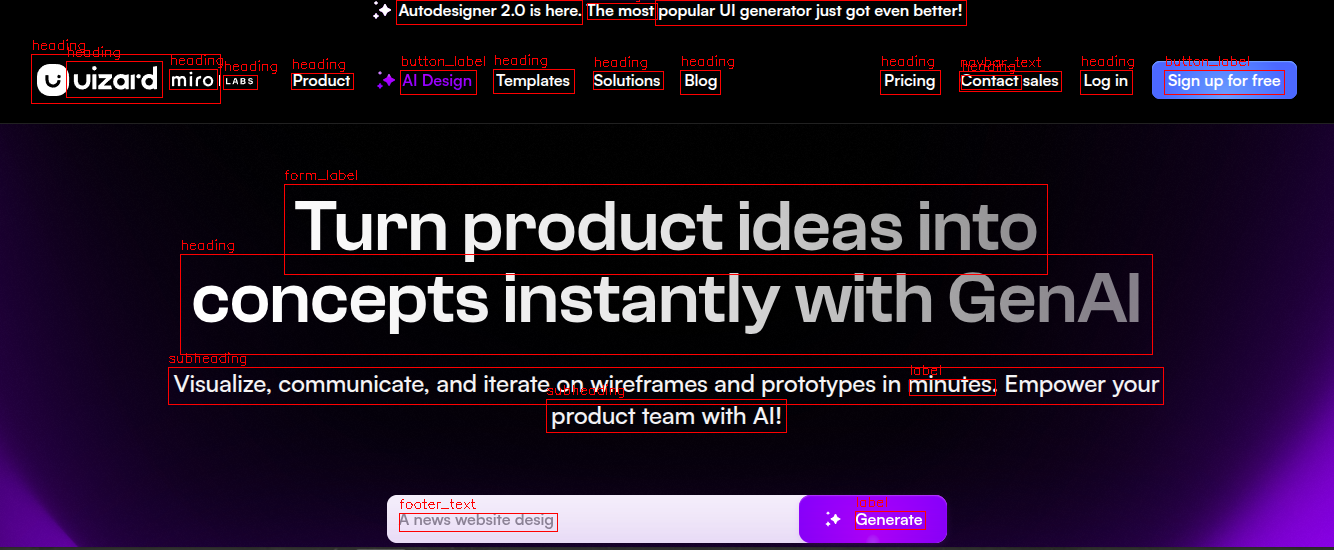

[{'text': 'Autodesigner 2.0 is here.',
  'type': 'button_label',
  'confidence': 0.65,
  'coordinates': [396, 0, 582, 24],
  'width': 186,
  'height': 24,
  'relative_position': [np.float64(0.297), np.float64(0.0)],
  'font_size': 24,
  'bg_color': '#000000'},
 {'text': 'The most',
  'type': 'heading',
  'confidence': 0.99,
  'coordinates': [587, 3, 657, 19],
  'width': 70,
  'height': 16,
  'relative_position': [np.float64(0.44), np.float64(0.005)],
  'font_size': 16,
  'bg_color': '#000000'},
 {'text': 'popular Ul generator just got even better!',
  'type': 'subheading',
  'confidence': 0.78,
  'coordinates': [655, 0, 966, 25],
  'width': 311,
  'height': 25,
  'relative_position': [np.float64(0.491), np.float64(0.0)],
  'font_size': 25,
  'bg_color': '#000000'},
 {'text': 'Juizard',
  'type': 'heading',
  'confidence': 0.98,
  'coordinates': [66, 61, 162, 97],
  'width': 96,
  'height': 36,
  'relative_position': [np.float64(0.049), np.float64(0.111)],
  'font_size': 36,
  'bg_color

In [8]:
import cv2
import numpy as np
import easyocr
import json
import os
from google.colab.patches import cv2_imshow

# Initialize OCR models
reader_standard = easyocr.Reader(['en'], gpu=True)
reader_handwritten = easyocr.Reader(['en'], gpu=True)

def extract_text_metadata_combined(
    image_path,
    output_folder="/content/drive/MyDrive/Sketch2Code_Dataset_new/test_images_metadata_json/",
    show=False
):
    """
    Detects + classifies text blocks (accurate version):
    heading, subheading, label, button, paragraph, navbar_text.
    Saves both image and metadata JSON to Drive.
    """

    # Ensure output folder exists
    os.makedirs(output_folder, exist_ok=True)

    # Extract filename (without extension)
    filename = os.path.splitext(os.path.basename(image_path))[0]

    # Define save paths
    save_path = os.path.join(output_folder, f"{filename}_ui_no_text.jpg")
    json_path = os.path.join(output_folder, f"{filename}_text_metadata.json")

    # --- Load image ---
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- Preprocess ---
    gray = cv2.equalizeHist(gray)
    if np.mean(gray) > 130:
        gray = 255 - gray

    adaptive = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 8
    )
    denoised = cv2.fastNlMeansDenoising(adaptive, None, 15, 7, 21)

    # --- Run OCR (both models) ---
    results = reader_standard.readtext(img, paragraph=False, detail=1)
    results += reader_handwritten.readtext(denoised, paragraph=False, detail=1)

    # --- IOU Helper ---
    def iou(b1, b2):
        x11, y11, x12, y12 = b1
        x21, y21, x22, y22 = b2
        xi1, yi1, xi2, yi2 = max(x11, x21), max(y11, y21), min(x12, x22), min(y12, y22)
        inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
        b1_area = (x12 - x11) * (y12 - y11)
        b2_area = (x22 - x21) * (y22 - y21)
        return inter / (b1_area + b2_area - inter + 1e-6)

    # --- Merge overlapping detections ---
    final_boxes = []
    for res in results:
        if len(res) < 2:
            continue
        bbox, text = res[:2]
        conf = res[2] if len(res) > 2 else 1.0
        if not text.strip() or conf < 0.25:
            continue

        pts = np.array(bbox).astype(int)
        x1, y1, x2, y2 = np.min(pts[:, 0]), np.min(pts[:, 1]), np.max(pts[:, 0]), np.max(pts[:, 1])

        skip = False
        for fb in final_boxes:
            if iou((x1, y1, x2, y2), fb[:4]) > 0.45:
                skip = True
                break
        if not skip:
            final_boxes.append([x1, y1, x2, y2, text, conf])

    # --- Analyze + classify ---
    text_blocks = []
    output = img.copy()

    keywords_button = {"submit", "login", "sign", "next", "send", "ok", "apply"}
    keywords_label = {"name", "email", "password", "user", "address", "country", "phone", "id"}
    keywords_nav = {"home", "menu", "about", "contact", "settings", "profile"}

    for (x1, y1, x2, y2, text, conf) in final_boxes:
        width, height = x2 - x1, y2 - y1
        if width <= 0 or height <= 0:
            continue

        rel_x, rel_y = x1 / w, y1 / h
        crop = img[y1:y2, x1:x2]
        avg_bg = np.median(crop.reshape(-1, 3), axis=0).astype(int) if crop.size > 0 else [255, 255, 255]
        bg_color = "#{:02x}{:02x}{:02x}".format(*avg_bg)
        gray_crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY) if crop.size > 0 else np.zeros((1, 1))
        font_intensity = np.mean(gray_crop)
        contrast = abs(np.mean(gray) - font_intensity)
        text_lower = text.lower().strip()

        # --- Classification rules ---
        if any(k in text_lower for k in keywords_nav) and rel_y < 0.2:
            text_type = "navbar_text"
        elif any(k in text_lower for k in keywords_button):
            text_type = "button_label"
        elif any(k in text_lower for k in keywords_label):
            text_type = "form_label"
        elif height > 0.08 * h or (len(text.split()) <= 3 and rel_y < 0.25):
            text_type = "heading"
        elif height > 0.04 * h:
            text_type = "subheading"
        elif len(text.split()) > 5:
            text_type = "paragraph"
        elif contrast > 80 and rel_y > 0.7:
            text_type = "footer_text"
        else:
            text_type = "label"

        # Draw placeholders
        color_tuple = tuple(int(c) for c in avg_bg)
        cv2.rectangle(output, (x1, y1), (x2, y2), color_tuple, -1)
        pencil_gray = np.random.randint(200, 230)
        cv2.rectangle(output, (x1, y1), (x2, y2), (pencil_gray, pencil_gray, pencil_gray), 1, cv2.LINE_AA)

        text_blocks.append({
            "text": text,
            "type": text_type,
            "confidence": round(float(conf), 2),
            "coordinates": [int(x1), int(y1), int(x2), int(y2)],
            "width": int(width),
            "height": int(height),
            "relative_position": [round(rel_x, 3), round(rel_y, 3)],
            "font_size": int(height),
            "bg_color": bg_color
        })

    # --- Save results to Drive ---
    cv2.imwrite(save_path, cv2.cvtColor(output, cv2.COLOR_RGB2BGR))
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(text_blocks, f, indent=2)

    print(f"✅ Processed: {len(text_blocks)} text blocks")
    print(f"🖼️ Image saved to: {save_path}")
    print(f"📝 JSON metadata saved to: {json_path}")

    if show:
        vis = img.copy()
        for tb in text_blocks:
            x1, y1, x2, y2 = tb["coordinates"]
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 1)
            cv2.putText(vis, tb["type"], (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 1)
        cv2_imshow(vis)

    return text_blocks


# ✅ Example Run
extract_text_metadata_combined(
    image_path="/content/drive/MyDrive/Sketch2Code_Dataset_new/test_sketches/uizard.png",
    output_folder="/content/drive/MyDrive/Sketch2Code_Dataset_new/test_images_metadata_json/",
    show=True
)


#Testing using trained after preprocessed

In [9]:
pip install ultralytics

In [12]:
from ultralytics import YOLO
import os
import pandas as pd
import json
import re   # for cleaning name

# -----------------------------
# 1️⃣ Load your trained model
# -----------------------------
model = YOLO("/content/drive/MyDrive/Sketch2Code_Model/best_model.pt")

# -----------------------------
# 2️⃣ Define input image path
# -----------------------------
image_path = "/content/drive/MyDrive/Sketch2Code_Dataset_new/test_sketches_preprocessed/preprocessed_uizard.png"

# -----------------------------
# 3️⃣ Clean image name for folder creation
# -----------------------------
# Extract filename without extension
base_name = os.path.splitext(os.path.basename(image_path))[0]

# Remove the word 'preprocessed' (case-insensitive)
clean_name = re.sub(r"(?i)preprocessed[_-]*", "", base_name).strip("_-")

# Folder where results will be saved (clean name)
save_dir = f"/content/drive/MyDrive/Sketch2Code_Dataset_new/Sketch2Code_Predictions/{clean_name}"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# 4️⃣ Run YOLO prediction and save annotated image
# -----------------------------
results = model.predict(
    source=image_path,
    imgsz=640,
    conf=0.25,
    save=True,
    device="0",
    project=save_dir,  # ✅ directly save annotated output in this folder
    name="",           # ✅ prevents extra 'predict_run_x' folders
)

# -----------------------------
# 5️⃣ Extract detection details (classes + coordinates)
# -----------------------------
for result in results:
    boxes = result.boxes
    data = []

    for box in boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().tolist()
        width = x2 - x1
        height = y2 - y1
        class_name = model.names[cls_id]

        data.append({
            "class_name": class_name,
            "confidence": round(conf, 3),
            "x1": round(x1, 2),
            "y1": round(y1, 2),
            "x2": round(x2, 2),
            "y2": round(y2, 2),
            "width": round(width, 2),
            "height": round(height, 2)
        })

    # Convert to DataFrame
    df = pd.DataFrame(data)

    # -----------------------------
    # 6️⃣ Save details to CSV and JSON
    # -----------------------------
    csv_path = os.path.join(save_dir, "detection_details.csv")
    json_path = os.path.join(save_dir, "detection_details.json")

    df.to_csv(csv_path, index=False)
    with open(json_path, "w") as f:
        json.dump(data, f, indent=4)

    print(f"✅ Prediction completed for: {clean_name}")
    print(f"📁 Results saved in: {save_dir}")
    print(f"🗒️ CSV saved as: {csv_path}")
    print(f"🗒️ JSON saved as: {json_path}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/drive/MyDrive/Sketch2Code_Dataset_new/test_sketches_preprocessed/preprocessed_uizard.png: 288x640 1 button, 1 image, 42.5ms
Speed: 2.3ms preprocess, 42.5ms inference, 1.5ms postprocess per image at shape (1, 3, 288, 640)
Results saved to /content/drive/MyDrive/Sketch2Code_Dataset_new/Sketch2Code_Predictions/uizard/predict2
✅ Prediction completed for: uizard
📁 Results saved in: /content/drive/MyDrive/Sketch2Code_Dataset_new/Sketch2Code_Predictions/uizard
🗒️ CSV saved as: /content/drive/MyDrive/Sketch2Code_Dataset_new/Sketch2Code_Predictions/uizard/detection_details.csv
🗒️ JSON saved as: /content/drive/MyDrive/Sketch2Code_Dataset_new/Sketch2Code_Predictions/uizar